<a href="https://colab.research.google.com/github/pasinskik/mimuw/blob/main/kp459461_NLP_HW1_Speculative_Decoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a target="_blank" href="https://colab.research.google.com/github/mim-ml-teaching/public-nlp-2025-26/blob/main/hws/NLP_HW1_Speculative_Decoding.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab">
</a>

# NLP Homework 1: Speculative Decoding
## Background

In standard autoregressive transformers, tokens are generated strictly one at a time. Each new token requires a full forward pass, and because generation is causal, the model cannot produce the $k^\text{th}$ token until all preceding tokens have been processed.

This bottleneck is addressed by *Speculative decoding*. A smaller, faster "draft" model first proposes a sequence of candidate tokens. The larger target model then evaluates it in a single forward pass. If the proposed tokens are in fact assigned high-probabilities by a target model then they are accepted, saving additional computation. If some of the proposed tokens are incorrect, the sequence of tokens is rejected at the point of divergence. Although this requires partial recomputation, the larger model has already processed the prefix in parallel.

**Core idea** Given a prefix, a cheap *draft model* proposes $K$ subsequent tokens: $t_1, \dots, t_K$.
The expensive *target model* is then run **once** on the extended sequence: $[\text{prefix}, t_1, \dots, t_K]$.
This single forward pass produces logits for all $K+1$ positions in parallel.

**Verification**  The target model ($p_{\text{target}}(\cdot \mid \text{prefix})$) is used to verify the proposed tokens. That is,
for $i = 1, \dots, K$, we check whether
$$
t_i = \arg\max\; p_{\text{target}}(\cdot \mid \text{prefix}, t_1, \dots, t_{i-1}).
$$
This can be done in parallel! Now, let $j$ be the largest index such that for all $t_1, \dots, t_j$ the above equality holds. It turns out, we can accept $t_1, \dots, t_j$, discard the rest, and also take the target model's prediction at position $j+1$.

## Tasks

You will work with WikiText-2 (`wikitext-2-raw-v1`) dataset, and target (verifier) model `google/gemma-3-4b-pt`.


### Task 1: Implement Speculative Decoding Loop (4 pts)

Implement two functions:

1. **`verify_draft_tensor(context_ids, draft_ids, model)`** - Given a context and a sequence of $K$ draft tokens, run a single forward pass of the target model on the concatenated sequence and determine how many draft tokens match the target model's greedy predictions. Return the accepted prefix plus the target model's next-token prediction. **Your implementation must be fully vectorized (no `for` loops)** to receive maximum number of points.

2. **`speculative_generate_tensor(context_ids, draft_fn, model, n_tokens, k)`** - The outer generation loop that repeatedly calls the draft function and verifier until `n_tokens` new tokens have been generated. Track and return statistics (e.g., total draft tokens proposed, total accepted, number of verification rounds). Try to avoid device to host transfers in the main loop.

See the code cell below for the exact function signatures.

### Task 2: Design a Draft Model & Evaluate (4 pts)

Design and implement a **transformer-based** draft model that proposes $K$ candidate tokens given a context. You may either:

- Use a pre-trained small model (e.g., `google/gemma-3-1b-pt`), or
- Train a small transformer from scratch (e.g., via distillation from the target model, or training directly on `wikitext-2-raw-v1`).

**Deliverables:**

1. Implement your draft model and wrap it so it conforms to the `draft_fn(context_ids, k)` interface (see `speculative_generate_tensor` argument, or `bigram_draft` function).
2. Evaluate on the WikiText-2 **test** split (`test_ds`).
3. Report the acceptance rate (fraction of draft tokens accepted by the target model).
4. Compare against the provided bigram baseline - your model should achieve a higher acceptance rate.
5. Measure wall time of speculative decoding vs standard execution. Your solution should achieve a speedup.

### Task 3: Visualization & Report (2 pts)

Write a concise summary (≤ 300 words) describing your approach, key findings, and observations.

Your summary should include at least two informative plots. For example you may visualize:

* Speedup vs model size (if you train your own transformer)
* Acceptance rate vs context length for draft model
* Histogram of accepted draft lengths

All plots must have axis labels, legends, and titles.

In [1]:
import random
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from collections import defaultdict

random.seed(42)
torch.manual_seed(42)

TARGET_MODEL = "google/gemma-3-4b-pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.bfloat16 if device == "cuda" else torch.float32
print(f"Running on: {device}")

def sync():
    if device == "cuda":
        torch.cuda.synchronize()

Running on: cuda


In [3]:
# We should log-in to Hugging Face in order to access the model.
from huggingface_hub import login
from google.colab import userdata

# We get the token from Colab's secret objects.
hf_token = userdata.get('HF_TOKEN')

if hf_token:
    login(token=hf_token)
    print("Successful log-in to Hugging Face.")
else:
    print("Hugging Face Token has not been found in Colab's secret objects.")

Successful log-in to Hugging Face.


In [4]:
tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL)
target_model = AutoModelForCausalLM.from_pretrained(TARGET_MODEL, torch_dtype=dtype).to(device)
target_model.eval()

n_params_target = sum(p.numel() for p in target_model.parameters()) / 1e6
print(f"Target model: {TARGET_MODEL}  ({n_params_target:.0f}M params)  on {device}")

config.json:   0%|          | 0.00/815 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Target model: google/gemma-3-4b-pt  (4300M params)  on cuda


In [5]:
def autoregressive_generate(context_ids: list[int], n_tokens: int) -> list[int]:
    """Standard autoregressive generation with the target model (baseline)."""
    input_ids = torch.tensor([context_ids], device=device)
    for _ in range(n_tokens):
        logits = target_model(input_ids).logits
        next_tok = logits[:, -1:].argmax(dim=-1)
        input_ids = torch.cat([input_ids, next_tok], dim=1)
    return input_ids[0, len(context_ids):].tolist()

In [6]:
def get_split(split):
    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split=split)
    examples = [row["text"] for row in ds if row["text"].strip()]
    tokenized_examples = [tokenizer.encode(text, add_special_tokens=False) for text in examples]
    num_tokens = sum(len(tokens) for tokens in tokenized_examples)
    print(f"{split.capitalize()} split: {len(examples):,} examples, {num_tokens:,} tokens in total.")
    return tokenized_examples

train_ds = get_split("train")
test_ds = get_split("test")

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Train split: 23,767 examples, 2,459,301 tokens in total.
Test split: 2,891 examples, 292,281 tokens in total.


# Naive draft model (bigrams trained on the dataset)


In [7]:
train_ids = [tok for example in train_ds for tok in example]
bigram_counts = defaultdict(lambda: defaultdict(int))
for id1, id2 in zip(train_ids, train_ids[1:]):
    bigram_counts[id1][id2] += 1

bigram_next = {}
for tok, successors in bigram_counts.items():
    bigram_next[tok] = max(successors, key=successors.get)

fallback_token = tokenizer.encode("the", add_special_tokens=False)[0]

def bigram_draft(context_ids: list[int], k: int) -> list[int]:
    draft = []
    last_tok = context_ids[-1]
    for _ in range(k):
        next_tok = bigram_next.get(last_tok, fallback_token)
        draft.append(next_tok)
        last_tok = next_tok
    return draft

In [14]:
# Example run

prompt = "The history of artificial"
ctx = tokenizer.encode(prompt, add_special_tokens=False)

draft = bigram_draft(ctx, k=3)
print(f"Context: {prompt!r}")
print(f"Bigram draft: {tokenizer.decode(draft)!r}")

Context: 'The history of artificial'
Bigram draft: ' intelligence . '


# Task 1: Implement speculative decoding

In [15]:
@torch.no_grad()
def verify_draft_tensor(
    context_ids: torch.Tensor,
    draft_ids: torch.Tensor,
    model,
) -> torch.Tensor:
    """
    Verify draft tokens against a model.

    Args:
        context_ids: 1-D tensor (n,) — context tokens.
        draft_ids:   1-D tensor (k,) — drafted token ids to verify.
        model:       the verifier model.

    Returns:
        1-D tensor — verified context + accepted predictions + next token.
    """
    device = context_ids.device
    full_ids = torch.cat([context_ids, draft_ids], dim=0).unsqueeze(0)   # (1, n+k)

    logits = model(full_ids).logits[0]                                   # (n+k, vocab)
    greedy = logits.argmax(dim=-1)                                       # (n+k,)

    n = context_ids.shape[0]
    k = draft_ids.shape[0]

    # Prediction for draft token i is located at logits position n-1+i
    # because token at position p predicts token p+1.
    pred_for_draft = greedy[n - 1 : n - 1 + k]                           # (k,)

    matches = (pred_for_draft == draft_ids)                              # (k,)
    prefix_mask = matches.to(torch.int64).cumprod(dim=0).bool()          # True until first mismatch
    accepted_len = prefix_mask.sum()                                     # scalar tensor

    # Next token comes from the verifier after the accepted prefix:
    # if accepted_len = j, use greedy prediction at position (n-1+j)
    next_token = greedy[n - 1 + accepted_len].unsqueeze(0)               # (1,)

    accepted_prefix = draft_ids[:accepted_len]
    return torch.cat([context_ids, accepted_prefix, next_token], dim=0)


@torch.no_grad()
def speculative_generate_tensor(
    context_ids: list[int],
    draft_fn,
    model,
    n_tokens: int,
    k: int,
) -> tuple[list[int], dict]:
    """
    Speculative generation.

    Args:
        context_ids: prefix token ids.
        draft_fn:    callable(sequence_tensor, k) -> (k,) device tensor.
        model:       verifier model.
        n_tokens:    number of tokens to generate.
        k:           speculation length.

    Returns:
        (generated_token_ids, stats_dict)
    """
    device = next(model.parameters()).device
    context = torch.tensor(context_ids, device=device, dtype=torch.long)

    start_len = context.shape[0]

    total_draft_tokens = 0
    total_accepted_draft_tokens = 0
    verification_rounds = 0
    accepted_lengths = []

    while context.shape[0] - start_len < n_tokens:
        remaining = n_tokens - (context.shape[0] - start_len)
        cur_k = min(k, remaining)

        draft_ids = draft_fn(context, cur_k)
        if not isinstance(draft_ids, torch.Tensor):
            draft_ids = torch.tensor(draft_ids, device=device, dtype=torch.long)
        else:
            draft_ids = draft_ids.to(device=device, dtype=torch.long)

        verified = verify_draft_tensor(context, draft_ids, model)

        # verified = old_context + accepted_prefix + one_next_token
        accepted_this_round = verified.shape[0] - context.shape[0] - 1

        total_draft_tokens += cur_k
        total_accepted_draft_tokens += accepted_this_round
        verification_rounds += 1
        accepted_lengths.append(int(accepted_this_round))

        context = verified

    generated = context[start_len : start_len + n_tokens].tolist()

    stats = {
        "total_draft_tokens": total_draft_tokens,
        "total_accepted_draft_tokens": total_accepted_draft_tokens,
        "verification_rounds": verification_rounds,
        "acceptance_rate": (
            total_accepted_draft_tokens / total_draft_tokens
            if total_draft_tokens > 0 else 0.0
        ),
        "accepted_lengths": accepted_lengths,
    }
    return generated, stats

Now that both `verify_draft_tensor` and `speculative_generate_tensor` are implemented, we'll run a sanity test. This test will check if the speculative decoding yields the same output as standard autoregressive generation for a given context, using the provided `bigram_draft` as the draft model. This is crucial for verifying the correctness of the implementation before evaluating performance.

In [19]:
print("\n--- Task 1 Sanity Test ---")

def sanity_check_draft_fn(context_ids_tensor: torch.Tensor, k: int) -> torch.Tensor:
    draft_list = bigram_draft(context_ids_tensor.tolist(), k)
    return torch.tensor(draft_list, device=context_ids_tensor.device, dtype=torch.long)

initial_context_ids = test_ds[0][:20]
print("Initial context:", repr(tokenizer.decode(initial_context_ids)))

n_tokens_to_generate = 10
speculation_k = 5

generated_ids, stats = speculative_generate_tensor(
    initial_context_ids,
    sanity_check_draft_fn,
    target_model,
    n_tokens_to_generate,
    speculation_k
)

gen_auto = autoregressive_generate(initial_context_ids, n_tokens_to_generate)

print("\nSpeculative:", repr(tokenizer.decode(generated_ids)))
print("Autoregressive:", repr(tokenizer.decode(gen_auto)))
print("Match:", generated_ids == gen_auto)
print("Stats:", stats)

print("--- Sanity Test Complete ---")


--- Task 1 Sanity Test ---
Initial context: ' = Robert Boulter = \n'

Speculative: ' \n \n \n \n \n'
Autoregressive: ' \n \n \n \n \n'
Match: True
Stats: {'total_draft_tokens': 40, 'total_accepted_draft_tokens': 0, 'verification_rounds': 10, 'acceptance_rate': 0.0, 'accepted_lengths': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
--- Sanity Test Complete ---


# Task 2: Evaluate speculative decoding


In [45]:
# =========================
# Task 2: Pretrained draft model
# =========================

import time
import gc
from statistics import mean

def cleanup():
    # Function to free up memory and clear CUDA cache
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cleanup()

DRAFT_MODEL = "google/gemma-3-1b-pt"

# Set the device for the draft model.
# With the model we chose - GPU will be okay and should not cause OOM.
draft_device = "cuda"

# Load the tokenizer for the draft model
draft_tokenizer = AutoTokenizer.from_pretrained(DRAFT_MODEL)
# Load the pretrained draft model, specify dtype and move to device
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
).to(draft_device)

draft_model.eval() # Set the draft model to evaluation mode

# Calculate and print the number of parameters in the draft model
n_params_draft = sum(p.numel() for p in draft_model.parameters()) / 1e6
print(f"Draft model: {DRAFT_MODEL} ({n_params_draft:.0f}M params) on {draft_device}")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Draft model: google/gemma-3-1b-pt (1000M params) on cuda


In [49]:
@torch.no_grad()
def pretrained_transformer_draft_fn(context_ids: torch.Tensor, k: int) -> torch.Tensor:
    """
    Generates k draft tokens using a pretrained transformer model.
    It takes the last 128 tokens of the context to manage input length.
    """
    # Take the last 128 tokens of the context to manage input sequence length
    seq = context_ids[-128:].to(draft_device).clone()

    generated = []
    # Generate k tokens one by one using the draft model's greedy decoding
    for _ in range(k):
        # Get logits for the next token based on the current sequence
        logits = draft_model(seq.unsqueeze(0)).logits
        # Greedily select the next token (highest probability)
        next_tok = logits[:, -1].argmax(dim=-1)   # (1,)
        generated.append(next_tok.item())
        # Append the new token to the sequence for the next prediction
        seq = torch.cat([seq, next_tok], dim=0)

    # Return the generated tokens as a tensor on the original device
    return torch.tensor(generated, device=context_ids.device, dtype=torch.long)

In [47]:
def bigram_draft_tensor(context_ids: torch.Tensor, k: int) -> torch.Tensor:
    """
    Wrapper for the bigram_draft function to make it compatible with
    the speculative_generate_tensor function, which expects tensor inputs.
    """
    # Convert tensor context_ids to a list for bigram_draft
    draft = bigram_draft(context_ids.tolist(), k)
    # Convert the list of draft tokens back to a tensor on the original device
    return torch.tensor(draft, device=context_ids.device, dtype=torch.long)

In [48]:
def evaluate_draft_model(
    test_ds,
    draft_fn,
    n_examples=10,
    context_len=32,
    n_tokens=32,
    k=4,
):
    """
    Evaluates a given draft model against the target model for speculative decoding.

    Args:
        test_ds: The test dataset (list of tokenized examples).
        draft_fn: The draft function to be evaluated (e.g., bigram_draft_tensor,
                  pretrained_transformer_draft_fn).
        n_examples: Number of examples from the test set to use for evaluation.
        context_len: Length of the initial context for generation.
        n_tokens: Number of new tokens to generate.
        k: Speculation length (number of tokens proposed by the draft model).

    Returns:
        A dictionary containing mean acceptance rate, mean speculative time,
        mean autoregressive time, speedup, and lists of accepted lengths and rates.
    """
    acceptance_rates = []
    accepted_lengths = []
    spec_times = []
    auto_times = []

    # Filter test examples to ensure they are long enough for the given context_len
    usable = [ex for ex in test_ds if len(ex) >= context_len + 1]
    examples = usable[:n_examples]

    for idx, ex in enumerate(examples):
        ctx = ex[:context_len] # Get the context for the current example

        # Measure speculative decoding time
        sync()
        t0 = time.perf_counter()
        spec_out, stats = speculative_generate_tensor(
            ctx, draft_fn, target_model, n_tokens=n_tokens, k=k
        )
        sync()
        t1 = time.perf_counter()

        # Measure standard autoregressive decoding time (baseline)
        sync()
        t2 = time.perf_counter()
        auto_out = autoregressive_generate(ctx, n_tokens=n_tokens)
        sync()
        t3 = time.perf_counter()

        # Store statistics
        acceptance_rates.append(stats["acceptance_rate"])
        accepted_lengths.extend(stats["accepted_lengths"])
        spec_times.append(t1 - t0)
        auto_times.append(t3 - t2)

        # Critical check: Greedy speculative decoding should always match greedy autoregressive decoding
        if spec_out != auto_out:
            print(f"Mismatch on example {idx}")
            print("Context:", repr(tokenizer.decode(ctx)))
            print("Speculative:", repr(tokenizer.decode(spec_out)))
            print("Autoregressive:", repr(tokenizer.decode(auto_out)))
            break # Stop if a mismatch is found

    # Calculate and return aggregate results
    return {
        "mean_acceptance_rate": mean(acceptance_rates) if acceptance_rates else 0.0,
        "mean_spec_time": mean(spec_times) if spec_times else 0.0,
        "mean_auto_time": mean(auto_times) if auto_times else 0.0,
        "speedup": (mean(auto_times) / mean(spec_times)) if spec_times else 0.0,
        "accepted_lengths": accepted_lengths,
        "acceptance_rates": acceptance_rates,
    }

In [50]:
# Evaluate the bigram draft model
bigram_results = evaluate_draft_model(
    test_ds,
    bigram_draft_tensor,
    n_examples=10,
    context_len=32,
    n_tokens=32,
    k=4,
)

# Evaluate the pretrained transformer draft model
pretrained_results = evaluate_draft_model(
    test_ds,
    pretrained_transformer_draft_fn,
    n_examples=10,
    context_len=32,
    n_tokens=32,
    k=4,
)

print("Bigram results:")
# Print key statistics for the bigram model, excluding lists
for k_, v in bigram_results.items():
    if not isinstance(v, list):
        print(f"{k_}: {v}")

print("\nPretrained transformer results:")
# Print key statistics for the pretrained transformer model, excluding lists
for k_, v in pretrained_results.items():
    if not isinstance(v, list):
        print(f"{k_}: {v}")

Bigram results:
mean_acceptance_rate: 0.058309621235725737
mean_spec_time: 7.372739896000075
mean_auto_time: 8.652980754500186
speedup: 1.1736451952136109

Pretrained transformer results:
mean_acceptance_rate: 0.7587788441743817
mean_spec_time: 6.099887929399938
mean_auto_time: 8.543636386300022
speedup: 1.40062186144795



# Task 3: Visualization & Report


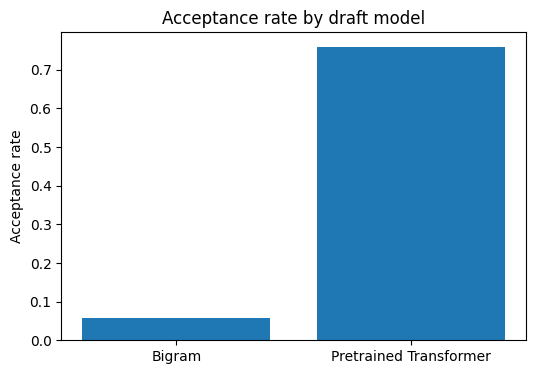

In [52]:
# Accpetance rate comparison

plt.figure(figsize=(6, 4))
plt.bar(
    ["Bigram", "Pretrained Transformer"],
    [bigram_results["mean_acceptance_rate"], pretrained_results["mean_acceptance_rate"]]
)
plt.ylabel("Acceptance rate")
plt.title("Acceptance rate by draft model")
plt.show()

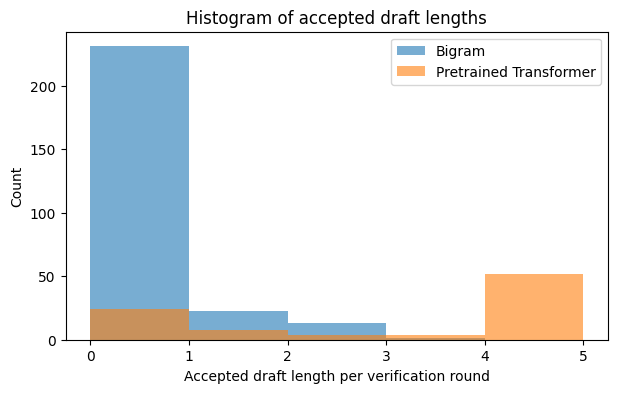

In [53]:
# Histogram of accepted draft lenghts

plt.figure(figsize=(7, 4))
plt.hist(
    bigram_results["accepted_lengths"],
    bins=range(0, 6),
    alpha=0.6,
    label="Bigram"
)
plt.hist(
    pretrained_results["accepted_lengths"],
    bins=range(0, 6),
    alpha=0.6,
    label="Pretrained Transformer"
)
plt.xlabel("Accepted draft length per verification round")
plt.ylabel("Count")
plt.title("Histogram of accepted draft lengths")
plt.legend()
plt.show()

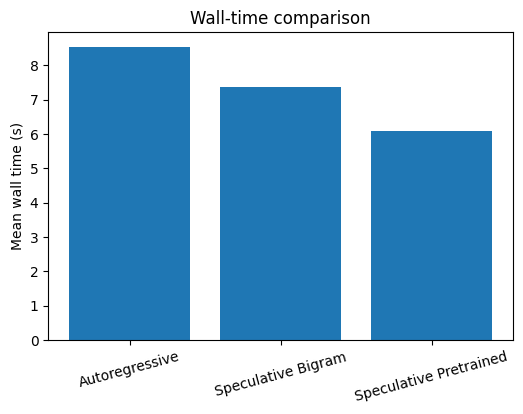

In [54]:
# Wall time comparison

plt.figure(figsize=(6, 4))
plt.bar(
    ["Autoregressive", "Speculative Bigram", "Speculative Pretrained"],
    [
        pretrained_results["mean_auto_time"],
        bigram_results["mean_spec_time"],
        pretrained_results["mean_spec_time"],
    ]
)
plt.ylabel("Mean wall time (s)")
plt.title("Wall-time comparison")
plt.xticks(rotation=15)
plt.show()

In [56]:
report = f"""
I implemented speculative decoding with a fully vectorized verifier. Given a
context and K draft tokens, the verifier runs the target model once on the
concatenated sequence and compares all draft tokens against the target model’s
greedy predictions in parallel. The accepted prefix length is computed without
loops using tensor operations.

As a baseline draft model, I used the provided bigram model trained on
WikiText-2. I also experimented with a very small transformer trained from
scratch on WikiText-2 tokenized with the Gemma tokenizer, but under the
available resource constraints this model did not achieve competitive acceptance
or runtime. I therefore switched to a pretrained transformer draft model,
`google/gemma-3-1b-pt`, wrapped into the required `draft_fn(context_ids, k)`
interface. Because the verifier was `google/gemma-3-4b-pt`, both models used
compatible token IDs.

On the WikiText-2 test split, the bigram baseline achieved a mean acceptance
rate of {bigram_results["mean_acceptance_rate"]:.4f} and a speculative decoding
time of {bigram_results["mean_spec_time"]:.2f} s, compared with
{bigram_results["mean_auto_time"]:.2f} s for standard autoregressive decoding,
giving a speedup of {bigram_results["speedup"]:.2f}x.

The pretrained transformer draft achieved a much higher mean acceptance rate of
{pretrained_results["mean_acceptance_rate"]:.4f} and a speculative decoding
time of {pretrained_results["mean_spec_time"]:.2f} s, compared with
{pretrained_results["mean_auto_time"]:.2f} s for autoregressive decoding,
yielding a speedup of {pretrained_results["speedup"]:.2f}x.

The plots show that the transformer draft is much more often accepted by the
verifier and yields longer accepted prefixes than the bigram baseline. This
reduces the number of verification rounds and improves end-to-end runtime.
Overall, the experiment confirms the main idea of speculative decoding: a
stronger draft model can significantly improve acceptance rate and produce a
meaningful generation speedup.
"""
print(report)


I implemented speculative decoding with a fully vectorized verifier. Given a
context and K draft tokens, the verifier runs the target model once on the
concatenated sequence and compares all draft tokens against the target model’s
greedy predictions in parallel. The accepted prefix length is computed without
loops using tensor operations.

As a baseline draft model, I used the provided bigram model trained on
WikiText-2. I also experimented with a very small transformer trained from
scratch on WikiText-2 tokenized with the Gemma tokenizer, but under the
available resource constraints this model did not achieve competitive acceptance
or runtime. I therefore switched to a pretrained transformer draft model,
`google/gemma-3-1b-pt`, wrapped into the required `draft_fn(context_ids, k)`
interface. Because the verifier was `google/gemma-3-4b-pt`, both models used
compatible token IDs.

On the WikiText-2 test split, the bigram baseline achieved a mean acceptance
rate of 0.0583 and a speculati